# Tutorial

## 00 - globals

In [1]:
import os
from stamp.config import adata_dir

In [2]:
slides = {
    1: {
        "exprmat": "exprMat_file.csv.gz",
        "metadata": "metadata_file.csv.gz",
        "fov_positions": "fov_positions_file.csv.gz",
    }
}
# optional filepath prefix
data_dir = "data"

In [3]:
for slide, d in slides.items():
    if not isinstance(slide, int):
        raise ValueError(f"Keys for dictionary `slides` must be integer values, not {type(slide)=} (found {slide=})")
    for k, v in d.items():
        f = os.path.join(data_dir, v)
        if not os.path.exists(f):
            raise FileNotFoundError(f)

In [4]:
os.makedirs(adata_dir, exist_ok=True)

## 01 - Read

In [5]:
import pandas as pd
import scanpy as sc
from stamp.config import sample_md_columns, adata_dir
from stamp.read import read_cosmx

In [6]:
sample_df = pd.read_table("data/sample2fov.csv", sep=",")
sample_df.sort_values(["slide", "fov_start"], inplace=True)
sample_df

,Donor,Treatment,Timepoint,sample,slide,fov_start,fov_end
0,6,Medium,1h,Medium_1h_don6,1,1,9
1,5,Medium,1h,Medium_1h_don5,1,10,18
2,4,Medium,1h,Medium_1h_don4,1,19,27
3,3,Medium,1h,Medium_1h_don3,1,28,36
4,2,Medium,1h,Medium_1h_don2,1,37,45
...,...,...,...,...,...,...,...
91,5,NaCl+Taurine,24h,NaCl+Taurine_24h_don5,2,388,396
92,4,NaCl+Taurine,24h,NaCl+Taurine_24h_don4,2,397,405
93,3,NaCl+Taurine,24h,NaCl+Taurine_24h_don3,2,406,414
94,2,NaCl+Taurine,24h,NaCl+Taurine_24h_don2,2,415,423


In [7]:
for col in sample_md_columns:
    if col not in sample_df.columns:
        raise ValueError(f"column={col} not found in sample_df")
for slide in slides:
    if slide not in set(sample_df["slide"]):
        raise ValueError(f"{slide=} not found in sample_df['slide']")

In [8]:
adata_file = os.path.join(adata_dir, "raw_data.h5ad")
read_cosmx(
    slides,
    sample_df,
    adata_file,
    # sample_df_columns=["Donor", "Treatment", "Timepoint"],
    # metadata_df_columns=[
    #     'nCount_RNA', 'nFeature_RNA', "nCount_negprobes", "nCount_falsecode", "Area.um2", "qcFlagsFOV"
    # ],
    # nrows=100,
    data_dir=data_dir,
    overwrite=False,
    verbose=True,
)

overwrite=False. Returning preloaded data


In [9]:
adata = sc.read_h5ad(adata_file)
adata.obs

,fov,cell_ID,slide,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,Mean.PanCK,...,errorCtPerCellEstimate,percOfDataFromErrorPerCell,qcFlagsFOV,cell,sample,Donor,Treatment,Timepoint,fov_start,fov_end
slide-fov-cell_ID,,,,,,,,,,,,,,,,,,,,,
1-1-17,1,17,1,3240,0.89,3792,840,65,73,882.7,...,97.281767,0.142455,Pass,c_2_1_17,Medium_1h_don6,6,Medium,1h,1,9
1-1-50,1,50,1,5656,0.85,3348,1026,105,89,994.9,...,97.281767,0.142455,Pass,c_2_1_50,Medium_1h_don6,6,Medium,1h,1,9
1-1-546,1,546,1,5500,0.98,3715,3090,87,85,839.7,...,97.281767,0.142455,Pass,c_2_1_546,Medium_1h_don6,6,Medium,1h,1,9
1-1-698,1,698,1,3604,0.87,3932,3467,77,67,884.6,...,97.281767,0.142455,Pass,c_2_1_698,Medium_1h_don6,6,Medium,1h,1,9
1-1-774,1,774,1,2604,0.82,893,3653,55,67,1553.3,...,97.281767,0.142455,Pass,c_2_1_774,Medium_1h_don6,6,Medium,1h,1,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1-428-735,428,735,1,4188,0.92,2419,3332,79,73,517.9,...,61.534091,0.119327,Pass,c_2_428_735,Medium_4h_don3,3,Medium,4h,424,432
1-428-833,428,833,1,2932,0.94,2522,3986,65,61,430.5,...,61.534091,0.119327,Pass,c_2_428_833,Medium_4h_don3,3,Medium,4h,424,432
1-429-8,429,8,1,2936,0.85,869,90,67,57,695.6,...,94.791667,0.178882,Pass,c_2_429_8,Medium_4h_don3,3,Medium,4h,424,432


## 02 - QC

In [10]:
import matplotlib.pyplot as plt

from stamp.qc import slide_qc_data, slide_qc_plots, violin, gene_qc, plot_ncell_per_condition, plot_value_distribution, plot_distribution

In [11]:
fov_df = slide_qc_data(adata, slides, data_dir)
fov_df

/home/siebrenf/git/stamp/stamp/qc.py:78: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fov_df["slide-fov"].replace(slidefov2passfail).replace({"Pass": 0, "Fail": 1})


,slide-fov,slide,fov,x,y,nCounts,nCell,meanCountsPerCell,nCount_negprobes,mean_NegProbe-CountsPerCell,nCount_falsecode,mean_FalseCode-CountsPerCell,meanCellSize,Failed_AtoMX_QC
0,1-1,1,1,256,145130,5556,7,793.714286,1,0.142857,32,4.571429,58.018832,0
1,1-2,1,2,4512,145130,6140,11,558.181818,2,0.181818,33,3.000000,45.164922,0
2,1-3,1,3,8768,145130,5061,4,1265.250000,3,0.750000,23,5.750000,91.449104,0
3,1-4,1,4,256,140874,8240,14,588.571429,2,0.142857,37,2.642857,45.700784,0
4,1-5,1,5,4512,140874,12586,19,662.421053,7,0.368421,74,3.894737,49.871777,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,1-425,1,425,63155,68921,666,2,333.000000,0,0.000000,1,0.500000,30.844722,0
347,1-427,1,427,58899,64665,956,3,318.666667,1,0.333333,3,1.000000,39.081555,0
348,1-428,1,428,63155,64665,2348,5,469.600000,1,0.200000,11,2.200000,48.113137,0
349,1-429,1,429,67411,64665,101,1,101.000000,0,0.000000,0,0.000000,42.476597,0


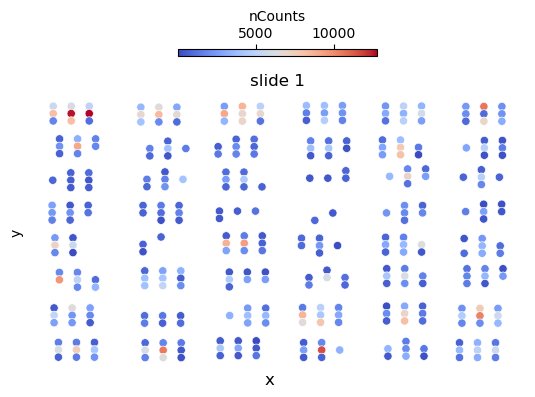

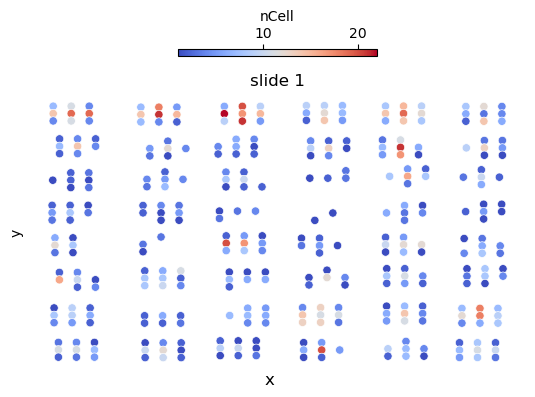

In [12]:
fig_axs_list = slide_qc_plots(fov_df[["slide", "x", "y", "nCounts", "nCell"]])
plt.show()

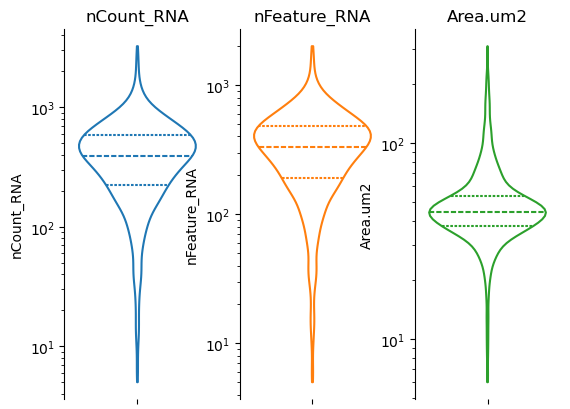

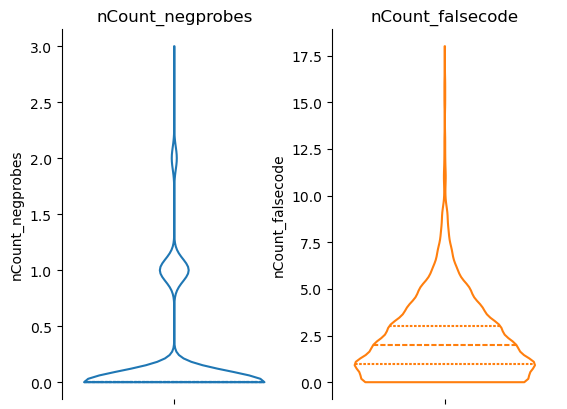

In [13]:
fig, axs = violin(adata, ["nCount_RNA", "nFeature_RNA", "Area.um2"])
plt.show()
fig, axs = violin(adata, ["nCount_negprobes", "nCount_falsecode"], log_scale=(False, False))
plt.show()

In [14]:
gene_qc(adata)
adata.var

,is_negctrl,is_sysctrl,nCell,pctCell,nTranscript,meanTranscript
ABCB7,False,False,45,2.25,49,0.0245
ABCB8,False,False,110,5.50,118,0.0590
ABCC1,False,False,67,3.35,72,0.0360
ABCC4,False,False,50,2.50,54,0.0270
ABCE1,False,False,148,7.40,161,0.0805
...,...,...,...,...,...,...
ZDHHC21,False,False,67,3.35,75,0.0375
ZFP36,False,False,572,28.60,800,0.4000
ZNF706,False,False,198,9.90,232,0.1160
ZNRF1,False,False,71,3.55,76,0.0380


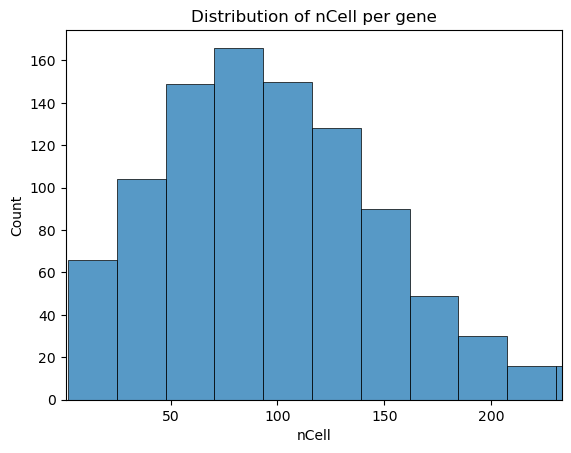

In [15]:
fig, ax = plot_distribution(adata, "nCell", axis=1)
plt.show()

## 03 - Filtering

In [16]:
from stamp.filter import genes_signal_to_noise, filter_genes, filter_cells

In [17]:
genes_signal_to_noise(adata, 1)

# randomly assign genes above noise threshold for test data
random_genes = adata.var.sample(n = round(len(adata.var) * 0.8), random_state=42).index
adata.var["above_noise"] = adata.var.index.isin(random_genes)

adata.var["above_noise"].value_counts()

above_noise
True     800
False    200
Name: count, dtype: int64

In [18]:
adata = filter_genes(adata, ncell_min=10)
adata = filter_cells(adata)

244 genes filtered out, 756 genes remaining.
888 cells filtered out, 1_112 cells remaining.


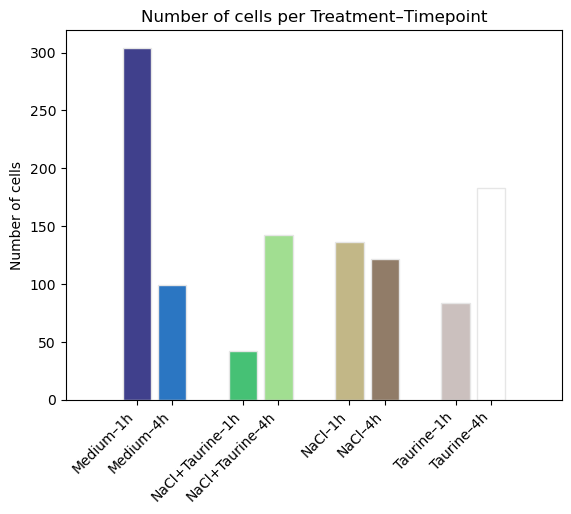

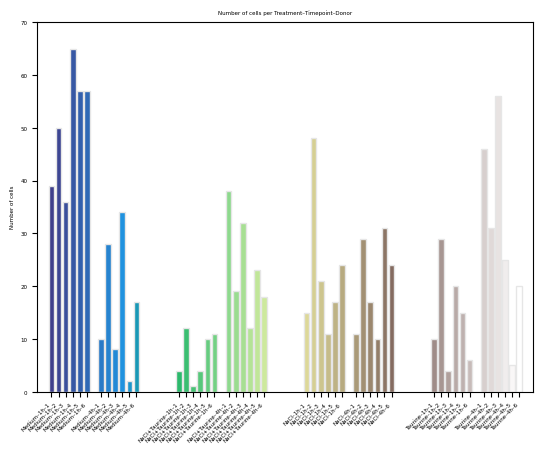

In [19]:
fig, ax = plot_ncell_per_condition(
    adata,
    columns = ["Treatment", "Timepoint"],
    offset_between_conditions = 1,
)
plt.show()
fig, ax = plot_ncell_per_condition(
    adata,
    columns = ["Treatment", "Timepoint", "Donor"],
    offset_between_conditions = [5, 1],
    text_kwargs={"size": 4},
)
plt.show()

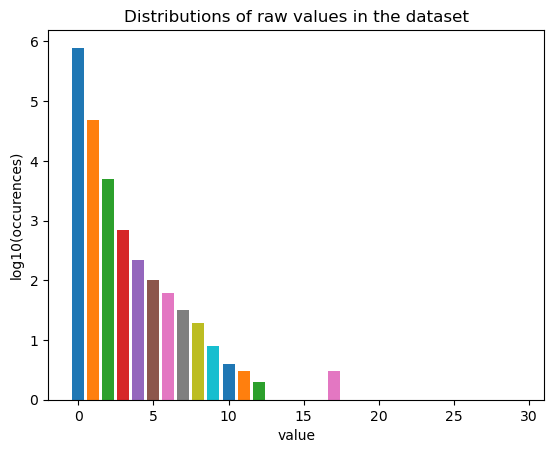

In [20]:
fig, ax = plot_value_distribution(adata)
plt.show()

# 04 - Binarize

In [21]:
from stamp.process import binarize

In [22]:
binarize(adata)
adata_file = os.path.join(adata_dir, "filtered.h5ad")
adata.write_h5ad(adata_file)

binary layer set as adata.X


In [23]:
adata.layers

Layers with keys: counts, binary

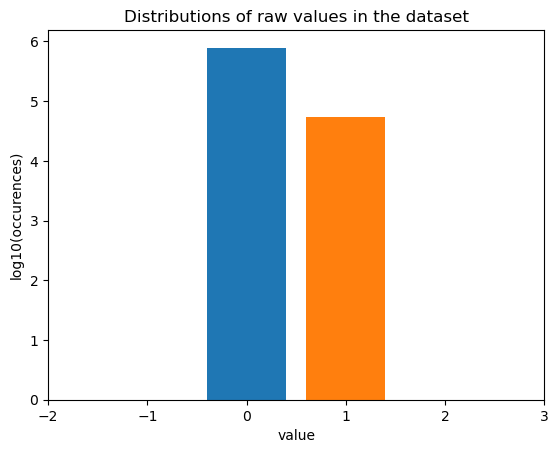

In [24]:
fig, ax = plot_value_distribution(adata)
plt.show()